# MC62 — LEAR C-shaped Dipole — `04_staircase_2Hz_morning` — Rotating Coil Analysis

**Magnet**: MC62 (red bulk C-shaped dipole)  
**Machine**: LEAR antiproton decelerator, CERN  
**Test**: `04_staircase_2Hz_morning` — streaming measurement (2026-02-17, morning repeat)  
**Rotation**: 2 Hz (120 rpm, ≈0.5 s per turn), 512 samples/turn  
**Current cycle**: precycles + staircase 0→+200→0→−200→0 A in 20 A steps (ramp rate 1 A/s)  
**PCBs**: Integral (R45, long coil) and Central (DQ, small coil)  
**Data format**: Binary streaming (corrected signals, 4 columns: time, abs flux, cmp flux, current)  

---
**Reproducibility test**: This is a morning repeat of test 03 (Feb 16 afternoon) with identical
measurement setup, to assess day-to-day reproducibility of the MC62 staircase measurement.

**Note on the large b2**: C-shaped dipoles have inherent left-right asymmetry (open gap
on one side, iron yoke on the other). This breaks the mid-plane symmetry that an H-dipole
would have, producing a systematic quadrupole gradient (b2) across the aperture.

**Note on precycles**: This measurement captured ~2 precycles (0→−200→+200→−200→0 A)
before the staircase, providing a view of the magnetic conditioning.


## 1. Configuration

Adjust parameters below, then **Run All**.

In [1]:
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────────────
MEAS_DIR = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                r"\measurements\MC62_20260217_094521_staircase_2Hz_morning\aperture1")

BIN_INTEGRAL = MEAS_DIR / "MC62_20260217_094521_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin"
BIN_CENTRAL  = MEAS_DIR / "MC62_20260217_094521_staircase_2Hz_corr_sigs_Ap_1_SegCentral.bin"

# FFMM results for parity check
FFMM_INTEGRAL = MEAS_DIR / "MC62_20260217_094521_staircase_2Hz_results_Ap_1_Seg_Integral.txt"
FFMM_CENTRAL  = MEAS_DIR / "MC62_20260217_094521_staircase_2Hz_results_Ap_1_Seg_Central.txt"

# Kn files -- external calibration (same PCBs as previous MC62 tests)
KN_DIR      = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer"
                   r"\measurements\2026_02_11_MC62\Kn values")
KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # 30 harmonics
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"  # 15 harmonics

# ── Magnet & coil parameters ─────────────────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]  (2/3 of 50 mm half-gap)
SAMPLES_PER_TURN = 512      # encoder samples per revolution (2 Hz rotation)
RPM              = 120      # rotation speed
T_PER_TURN       = 60.0 / RPM  # 0.5 s per turn

# ── Averaging & selection ───────────────────────────────────────────────────────
N_LAST_TURNS = 340          # average last 340 turns per plateau (skip first ~460 for settling)
N_SKIP_END   = 20           # skip last 20 turns per plateau (avoid ramp-start contamination)

# ── Plateau detection ─────────────────────────────────────────────────────────
# At 2 Hz with 1 A/s ramp, within-turn I variation during ramps is ~0.5 A.
# With threshold 1.5 ALL turns pass as plateau. Use 0.5 to separate ramps.
PLATEAU_I_RANGE_MAX = 0.5   # A (block-averaged I range threshold)
PLATEAU_MIN_LENGTH  = 50    # min turns per group (filters precycle fragments)
PLATEAU_MERGE_GAP   = 100   # merge consecutive groups at same I_nom if gap < this

# ── Sign convention ───────────────────────────────────────────────────────────
FLIP_FIELD_SIGN = True      # True = flip sign of all Tesla columns

# ── Pipeline options ──────────────────────────────────────────────────────────
OPTIONS        = ("dri", "rot", "cel", "fed")  # cel/fed applied if diagnostic says SAFE
PARITY_OPTIONS = ("dri", "rot", "cel", "fed", "dit")  # + dit to match FFMM C++ native
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6           # warm dipole: lower threshold for ok_main

# ── FFMM parity parameters ────────────────────────────────────────────────────
FFMM_R_REF = 0.33           # FFMM used R_REF=0.33 m in its results

print(f"MC62 04_staircase_2Hz_morning analysis")
print(f"  Rotation:  {RPM} rpm = {60/RPM:.2f} s/turn, {SAMPLES_PER_TURN} samples/turn")
print(f"  Averaging: last {N_LAST_TURNS} turns per plateau")
print(f"  R_ref:     {R_REF*1e3:.1f} mm (analysis) / {FFMM_R_REF*1e3:.0f} mm (FFMM)")
print(f"  Plateau threshold: {PLATEAU_I_RANGE_MAX} A, min_length={PLATEAU_MIN_LENGTH}")


MC62 04_staircase_2Hz_morning analysis
  Rotation:  120 rpm = 0.50 s/turn, 512 samples/turn
  Averaging: last 340 turns per plateau
  R_ref:     33.0 mm (analysis) / 330 mm (FFMM)
  Plateau threshold: 0.5 A, min_length=50


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

print("Imports ready.")

Imports ready.


## 2. Kn Calibration

External Kn files (same calibration used for all MC62 tests).  
**Note**: The measurement-embedded Kn files have only 15 harmonics (FFMM `n_multipoles=15`).
The Central embedded Kn is all-zeros (bug). We use the external files (30 harmonics integral, 15 central).

In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

for lbl, kn in [("Integral (R45)", kn_integral), ("Central (DQ)", kn_central)]:
    k1_abs = abs(kn.kn_abs[0])
    k1_cmp = abs(kn.kn_cmp[0])
    supp = k1_abs / max(k1_cmp, 1e-30)
    print(f"{lbl:20s}: {len(kn.orders):2d} harmonics, "
          f"k1_abs = {k1_abs:.6f}, suppression = {supp:.0f}x")

Integral (R45)      : 30 harmonics, k1_abs = 1.447495, suppression = 12924x
Central (DQ)        : 15 harmonics, k1_abs = 0.031959, suppression = 2302922349194870x


## 3. Load Binary Streaming Data

Binary format: 4 columns of `float64` â€” `[time_s, abs_flux, cmp_flux, I_dcct]`.  
File contains the entire measurement: precycles + staircase, ~35 800 turns.

In [4]:
Ns = SAMPLES_PER_TURN
N_COLS = 4  # time, abs_flux, cmp_flux, current

def load_binary_segment(bin_path):
    """Load a binary corrected-signals file into per-turn arrays."""
    raw = np.fromfile(str(bin_path), dtype="<f8")
    n_samples = len(raw) // N_COLS
    n_turns = n_samples // Ns
    n_keep = n_turns * Ns
    raw = raw[: n_keep * N_COLS].reshape(n_keep, N_COLS)
    t_all   = raw[:, 0].reshape(n_turns, Ns)
    ch1_all = raw[:, 1].reshape(n_turns, Ns)
    ch2_all = raw[:, 2].reshape(n_turns, Ns)
    I_all   = raw[:, 3].reshape(n_turns, Ns)
    return t_all, ch1_all, ch2_all, I_all, n_turns

print("Loading Integral binary...")
t_int, ch1_int, ch2_int, I_int, n_turns_int = load_binary_segment(BIN_INTEGRAL)
print(f"  {n_turns_int} turns, time span: {t_int[0,0]:.3f} â€“ {t_int[-1,-1]:.1f} s "
      f"({(t_int[-1,-1] - t_int[0,0])/60:.1f} min)")

print("Loading Central binary...")
t_cen, ch1_cen, ch2_cen, I_cen, n_turns_cen = load_binary_segment(BIN_CENTRAL)
print(f"  {n_turns_cen} turns")

# Channel detection from high-current turn (Integral)
I_mean_quick = I_int.mean(axis=1)
best_turn = np.argmax(np.abs(I_mean_quick))
rr1_int = robust_range(ch1_int[best_turn])
rr2_int = robust_range(ch2_int[best_turn])
SWAP_INT = rr2_int > rr1_int

flux_abs_int = ch2_int if SWAP_INT else ch1_int
flux_cmp_int = ch1_int if SWAP_INT else ch2_int
print(f"\nIntegral: col1 range={rr1_int:.3e}, col2 range={rr2_int:.3e}"
      f"  ->  {'SWAP' if SWAP_INT else 'no swap'}")

# Channel detection from high-current turn (Central)
I_mean_cen_q = I_cen.mean(axis=1)
best_turn_c = np.argmax(np.abs(I_mean_cen_q))
rr1_cen = robust_range(ch1_cen[best_turn_c])
rr2_cen = robust_range(ch2_cen[best_turn_c])
SWAP_CEN = rr2_cen > rr1_cen

flux_abs_cen = ch2_cen if SWAP_CEN else ch1_cen
flux_cmp_cen = ch1_cen if SWAP_CEN else ch2_cen
print(f"Central:  col1 range={rr1_cen:.3e}, col2 range={rr2_cen:.3e}"
      f"  ->  {'SWAP' if SWAP_CEN else 'no swap'}")

Loading Integral binary...
  32544 turns, time span: 0.001 â€“ 16447.0 s (274.1 min)
Loading Central binary...
  32544 turns

Integral: col1 range=1.453e-05, col2 range=1.268e-06  ->  no swap
Central:  col1 range=6.039e-07, col2 range=3.836e-08  ->  no swap


## cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` to check whether the centre-location +
feeddown correction is safe for this data.

In [5]:
# Use a sample of turns for the diagnostic (e.g., first 100 turns)
_n_diag = min(100, flux_abs_int.shape[0])
diag = diagnose_cel_fed(
    flux_abs_int[:_n_diag], flux_cmp_int[:_n_diag],
    t_int[:_n_diag], I_int[:_n_diag],
    kn=kn_integral, r_ref=R_REF, magnet_order=MAGNET_ORDER,
)
print(f"cel/fed diagnostic: {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _n_diag, _Bd

# Act on diagnostic: disable cel/fed if unsafe
if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")


cel/fed diagnostic: UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.1051, max 0.1102). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 3.6777e-06 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


## 4. Current Profile & Plateau Detection

Identify precycle turns, ramp turns, and staircase plateau turns using
the standard three-rule plateau detection.

Total turns: 32544
Plateau turns: 31605 / 32544
I range: -200.1 .. 200.1 A


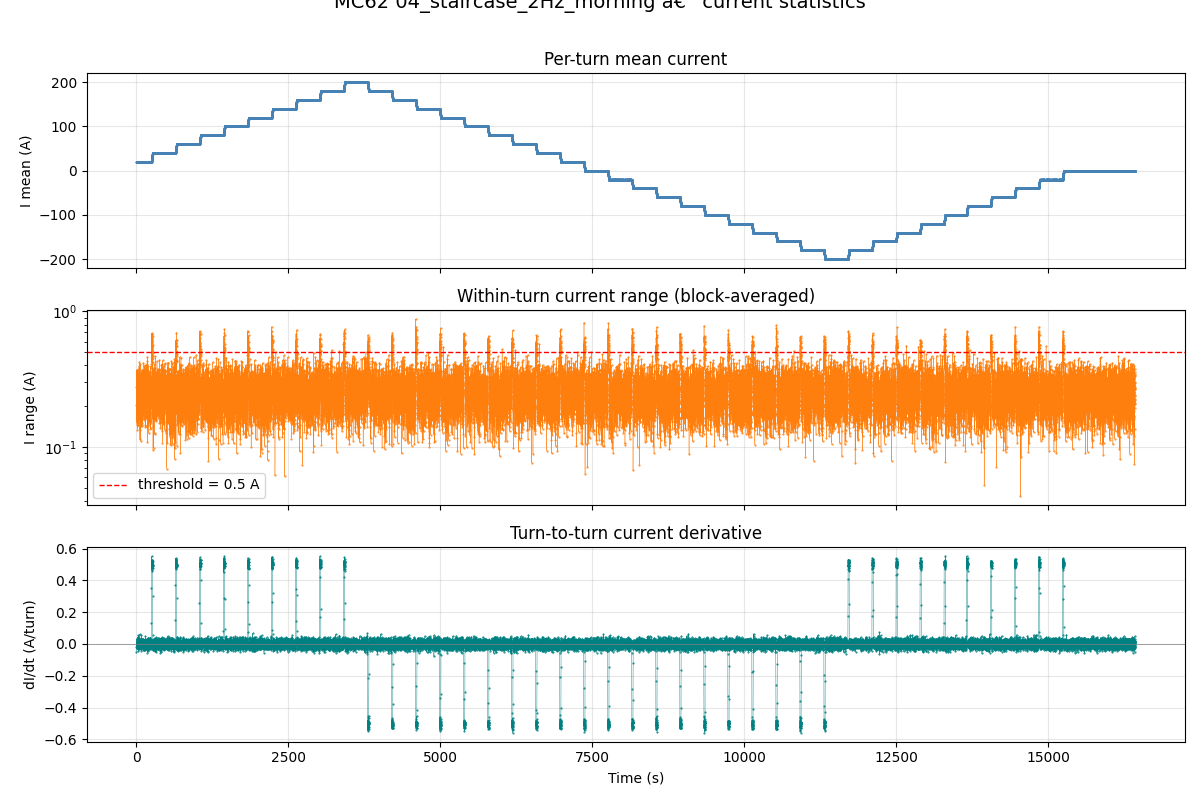

In [6]:
# Per-turn statistics
I_mean  = I_int.mean(axis=1)
t_mean  = t_int.mean(axis=1)

# Block-averaged current range
N_BLOCKS = 10
I_range, I_blocks = compute_block_averaged_range(I_int, Ns, N_BLOCKS)

# Plateau detection
plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
is_plateau = plateau_info["is_plateau"]

print(f"Total turns: {n_turns_int}")
print(f"Plateau turns: {is_plateau.sum()} / {n_turns_int}")
print(f"I range: {np.nanmin(I_mean):.1f} .. {np.nanmax(I_mean):.1f} A")

# Turn-to-turn dI/dt
dI_dt = np.gradient(I_mean)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(t_mean, I_mean, ".-", markersize=1, linewidth=0.3, color="steelblue")
ax.set_ylabel("I mean (A)")
ax.set_title("Per-turn mean current")

ax = axes[1]
ax.semilogy(t_mean, I_range, ".-", markersize=1, linewidth=0.3, color="tab:orange")
ax.axhline(PLATEAU_I_RANGE_MAX, color="red", ls="--", lw=1,
           label=f"threshold = {PLATEAU_I_RANGE_MAX} A")
ax.set_ylabel("I range (A)")
ax.set_title("Within-turn current range (block-averaged)")
ax.legend()

ax = axes[2]
ax.plot(t_mean, dI_dt, ".-", markersize=1, linewidth=0.3, color="teal")
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("dI/dt (A/turn)")
ax.set_xlabel("Time (s)")
ax.set_title("Turn-to-turn current derivative")

fig.suptitle("MC62 04_staircase_2Hz_morning â€” current statistics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Identify Precycles vs Staircase

Cluster contiguous plateau groups and identify the staircase region.
The precycles have long ramps with brief pauses at Â±200 A and 0 A;
the staircase has systematic 20 A steps with ~800 turns per plateau.

In [7]:
# Find contiguous plateau groups (min_length filters tiny precycle fragments)
plateau_groups_raw = find_contiguous_groups(is_plateau, min_length=PLATEAU_MIN_LENGTH)

# Build group info with I_nom
group_info = []
for gi, (gs, ge) in enumerate(plateau_groups_raw):
    I_grp = I_mean[gs:ge+1]
    t_grp = t_mean[gs:ge+1]
    I_nom = round(I_grp.mean() / 20) * 20
    group_info.append({
        "group": gi,
        "start": gs,
        "end": ge,
        "n_turns": ge - gs + 1,
        "I_mean": I_grp.mean(),
        "I_nom": I_nom,
        "I_std": I_grp.std(),
        "t_start": t_grp[0],
        "t_end": t_grp[-1],
    })

# Merge consecutive groups at the same I_nom with small gap (ramp splits)
merged = [group_info[0].copy()]
for g in group_info[1:]:
    prev = merged[-1]
    gap = g["start"] - prev["end"]
    if g["I_nom"] == prev["I_nom"] and gap < PLATEAU_MERGE_GAP:
        # Extend the previous group to cover both
        prev["end"] = g["end"]
        prev["n_turns"] = prev["end"] - prev["start"] + 1
        I_slice = I_mean[prev["start"]:prev["end"]+1]
        prev["I_mean"] = I_slice.mean()
        prev["I_std"] = I_slice.std()
        prev["t_end"] = t_mean[prev["end"]]
    else:
        merged.append(g.copy())

# Re-index
for i, g in enumerate(merged):
    g["group"] = i

df_groups = pd.DataFrame(merged)
print(f"Found {len(df_groups)} plateau groups (after merge)")

# Classify: staircase starts at first 0 A plateau with >= 500 turns
staircase_start_group = None
for i, row in df_groups.iterrows():
    if abs(row["I_nom"]) < 2.0 and row["n_turns"] >= 500:
        staircase_start_group = i
        break

if staircase_start_group is not None:
    # Check if "precycle" groups are actually systematic staircase steps
    if staircase_start_group > 0:
        pre_I = df_groups.iloc[:staircase_start_group]["I_nom"].values
        if len(pre_I) > 1:
            steps = np.abs(np.diff(pre_I))
            if np.all(steps <= 25):  # all <=25 A steps -> staircase, not precycle
                print("No precycle detected (systematic 20 A stepping from start)")
                staircase_start_group = 0
    staircase_start_turn = int(df_groups.loc[staircase_start_group, "start"])
    n_precycle_groups = staircase_start_group
    n_staircase_groups = len(df_groups) - staircase_start_group
    print(f"\nPrecycle region: groups 0â€“{staircase_start_group-1} "
          f"(turns 0â€“{staircase_start_turn-1})")
    print(f"Staircase region: groups {staircase_start_group}â€“{len(df_groups)-1} "
          f"(turns {staircase_start_turn}â€“{n_turns_int-1}), "
          f"{n_staircase_groups} plateaus")
else:
    staircase_start_turn = 0
    staircase_start_group = 0
    print("WARNING: could not identify staircase start, treating all data as staircase")

# Show group summary
print(f"\n{'Grp':>4s} {'Start':>7s} {'End':>7s} {'N':>6s} {'I_nom':>8s} {'Region':>10s}")
print("-" * 50)
for i, row in df_groups.iterrows():
    region = "precycle" if i < staircase_start_group else "staircase"
    print(f"{i:4d} {row['start']:7.0f} {row['end']:7.0f} {row['n_turns']:6.0f} "
          f"{row['I_nom']:+8.0f} {region:>10s}")

Found 40 plateau groups (after merge)
No precycle detected (systematic 20 A stepping from start)

Precycle region: groups 0â€“-1 (turns 0â€“-1)
Staircase region: groups 0â€“39 (turns 0â€“32543), 40 plateaus

 Grp   Start     End      N    I_nom     Region
--------------------------------------------------
   0       0     489    490      +20  staircase
   1     527    1271    745      +40  staircase
   2    1308    2052    745      +60  staircase
   3    2092    2834    743      +80  staircase
   4    2874    3616    743     +100  staircase
   5    3655    4397    743     +120  staircase
   6    4437    5179    743     +140  staircase
   7    5217    5962    746     +160  staircase
   8    6001    6731    731     +180  staircase
   9    6783    7525    743     +200  staircase
  10    7565    8307    743     +180  staircase
  11    8344    9090    747     +160  staircase
  12    9129    9871    743     +140  staircase
  13    9911   10653    743     +120  staircase
  14   10691   11435 

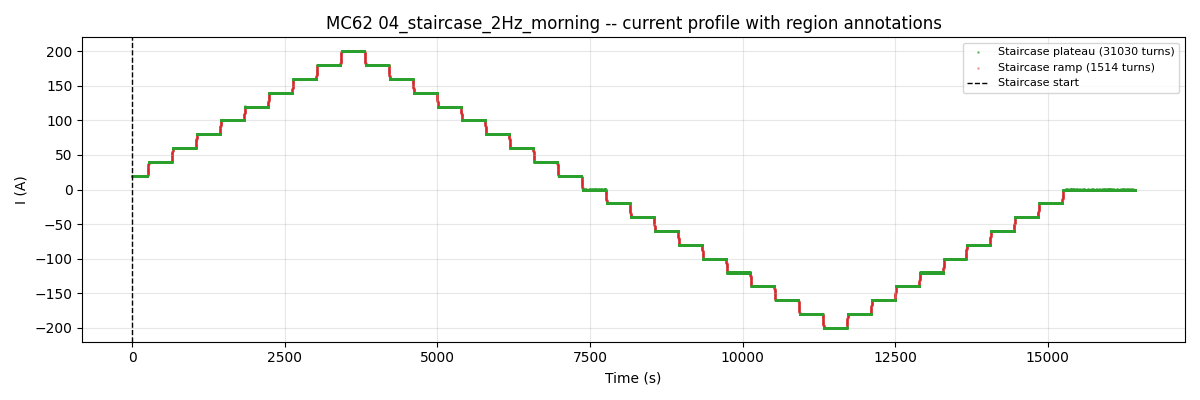

In [8]:
# Annotated current profile
fig, ax = plt.subplots(figsize=(12, 4))

# Background: all turns
ax.plot(t_mean, I_mean, linewidth=0.3, color="lightgrey", zorder=0)

# Build group membership mask from df_groups (staircase groups only)
_in_grp = np.zeros(n_turns_int, dtype=bool)
for _, _row in df_groups[df_groups.index >= staircase_start_group].iterrows():
    _s, _e = int(_row["start"]), int(_row["end"])
    _in_grp[_s:_e + 1] = True

# Precycle turns
pre_mask = np.arange(n_turns_int) < staircase_start_turn
if pre_mask.any():
    ax.scatter(t_mean[pre_mask], I_mean[pre_mask], s=1, color="tab:orange",
              alpha=0.3, label=f"Precycle ({pre_mask.sum()} turns)", zorder=1)

# Staircase plateau turns (in a staircase group)
stair_plateau = _in_grp & (~pre_mask)
ax.scatter(t_mean[stair_plateau], I_mean[stair_plateau], s=1, color="tab:green",
          alpha=0.5, label=f"Staircase plateau ({stair_plateau.sum()} turns)", zorder=2)

# Staircase ramp turns (not in any group, after staircase start)
stair_ramp = (~_in_grp) & (~pre_mask)
ax.scatter(t_mean[stair_ramp], I_mean[stair_ramp], s=1, color="tab:red",
          alpha=0.3, label=f"Staircase ramp ({stair_ramp.sum()} turns)", zorder=1)

ax.axvline(t_mean[staircase_start_turn], color="black", ls="--", lw=1,
           label="Staircase start")
ax.set_xlabel("Time (s)")
ax.set_ylabel("I (A)")
ax.set_title("MC62 04_staircase_2Hz_morning -- current profile with region annotations")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Assign Staircase Runs

Map each staircase plateau group to a run ID, nominal current, and branch direction.
This mimics the run-based structure of the previous MC62 tests.

In [9]:
# Build run-level metadata from staircase plateau groups
staircase_groups = df_groups[df_groups.index >= staircase_start_group].copy()
staircase_groups = staircase_groups.reset_index(drop=True)
staircase_groups["run_id"] = range(len(staircase_groups))

# Round nominal current to nearest 20 A
staircase_groups["I_nom"] = (staircase_groups["I_mean"] / 20).round() * 20

# Branch direction
branches = ["ascending"]
for i in range(1, len(staircase_groups)):
    if staircase_groups.iloc[i]["I_nom"] > staircase_groups.iloc[i-1]["I_nom"]:
        branches.append("ascending")
    elif staircase_groups.iloc[i]["I_nom"] < staircase_groups.iloc[i-1]["I_nom"]:
        branches.append("descending")
    else:
        branches.append(branches[-1])
staircase_groups["branch"] = branches

# Build a per-turn lookup: turn_idx -> (run_id, I_nom, branch, turn_in_run)
turn_run_map = {}
for _, row in staircase_groups.iterrows():
    start = int(row["start"])
    end = int(row["end"])
    for t in range(start, end + 1):
        turn_run_map[t] = {
            "run_id": int(row["run_id"]),
            "I_nom": row["I_nom"],
            "branch": row["branch"],
            "turn_in_run": t - start,
        }

print(f"Staircase: {len(staircase_groups)} plateaus")
print(f"\n{'Run':>4s} {'I_nom':>8s} {'Branch':>10s} {'Turns':>6s} {'Start':>7s} {'End':>7s}")
print("-" * 50)
for _, r in staircase_groups.iterrows():
    print(f"{r['run_id']:4.0f} {r['I_nom']:+8.0f} {r['branch']:>10s} "
          f"{r['n_turns']:6.0f} {r['start']:7.0f} {r['end']:7.0f}")

Staircase: 40 plateaus

 Run    I_nom     Branch  Turns   Start     End
--------------------------------------------------
   0      +20  ascending    490       0     489
   1      +40  ascending    745     527    1271
   2      +60  ascending    745    1308    2052
   3      +80  ascending    743    2092    2834
   4     +100  ascending    743    2874    3616
   5     +120  ascending    743    3655    4397
   6     +140  ascending    743    4437    5179
   7     +160  ascending    746    5217    5962
   8     +180  ascending    731    6001    6731
   9     +200  ascending    743    6783    7525
  10     +180 descending    743    7565    8307
  11     +160 descending    747    8344    9090
  12     +140 descending    743    9129    9871
  13     +120 descending    743    9911   10653
  14     +100 descending    745   10691   11435
  15      +80 descending    744   11474   12217
  16      +60 descending    745   12256   13000
  17      +40 descending    747   13034   13780
  18      +20

## Turn Classification Map

Every turn color-coded by type: plateau turns used for computation (green),
plateau turns still settling (gold), ramp turns (red), and transition turns
at plateau/ramp boundaries (orange/purple). Precycle turns shown in grey.

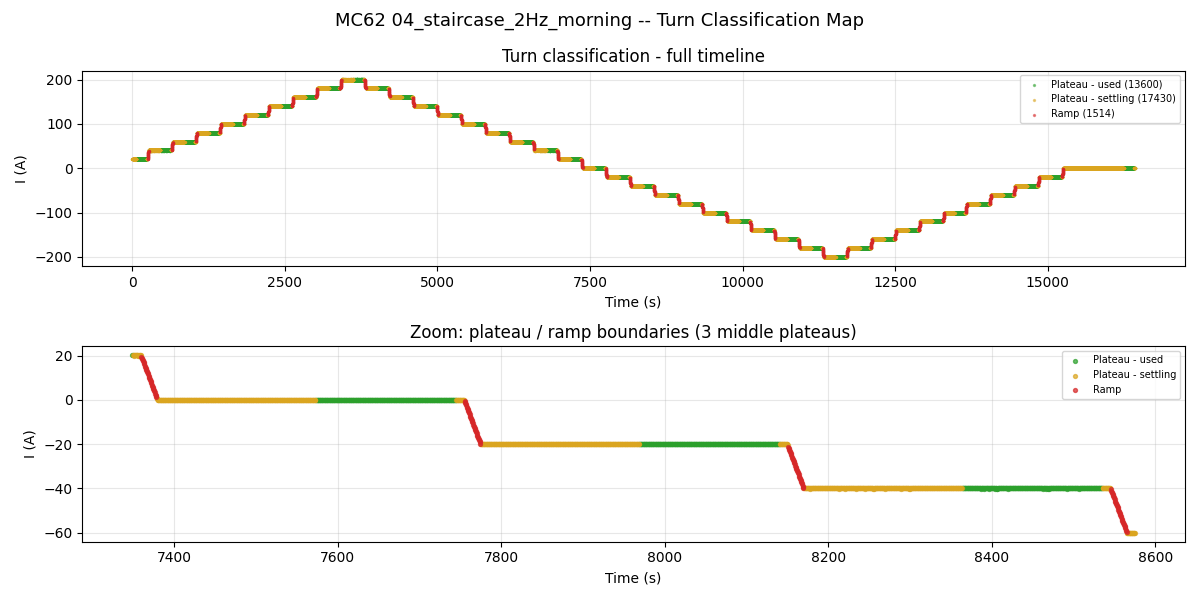


Turn classification summary (32544 total turns):
  Plateau - used                     :  13600  ( 41.8%)
  Plateau - settling                 :  17430  ( 53.6%)
  Ramp                               :   1514  (  4.7%)
  Precycle                           :      0  (  0.0%)
  TOTAL                              :  32544


In [10]:
# ── Classify every turn ────────────────────────────────────────────────
_n_skip_end = N_SKIP_END if "N_SKIP_END" in dir() else 0
_n_total = n_turns_int

# Build group membership mask: is this turn inside a staircase plateau group?
_in_group = np.zeros(_n_total, dtype=bool)
for _, _row in staircase_groups.iterrows():
    _s, _e = int(_row["start"]), int(_row["end"])
    _in_group[_s:_e + 1] = True

# Build "used for computation" mask
_is_used = np.zeros(_n_total, dtype=bool)
for _, _row in staircase_groups.iterrows():
    _s, _e = int(_row["start"]), int(_row["end"])
    _eff_end = _e - _n_skip_end
    _used_start = max(_s, _eff_end - N_LAST_TURNS + 1)
    if _used_start <= _eff_end:
        _is_used[_used_start:_eff_end + 1] = True

# Classification based on group membership (not plateau_info, which is too
# permissive at 2 Hz -- within-turn dI ~ 0.5 A is at the detection threshold)
_in_sc = np.arange(_n_total) >= staircase_start_turn
cat = np.empty(_n_total, dtype=object)
cat[~_in_sc] = "precycle"
cat[_in_sc & _in_group & _is_used] = "used"
cat[_in_sc & _in_group & ~_is_used] = "settling"
cat[_in_sc & ~_in_group] = "ramp"

# ── Styling ────────────────────────────────────────────────────────────
_CAT_STYLE = {
    "used":      ("tab:green",  "Plateau - used"),
    "settling":  ("goldenrod",  "Plateau - settling"),
    "ramp":      ("tab:red",    "Ramp"),
    "precycle":  ("grey",       "Precycle"),
}

# ── 2-panel figure ─────────────────────────────────────────────────────
fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(12, 6))

_counts = Counter(cat)
for cname, (color, label) in _CAT_STYLE.items():
    mask = cat == cname
    n = _counts.get(cname, 0)
    if n == 0:
        continue
    ax_full.scatter(t_mean[mask], I_mean[mask], s=2, alpha=0.5,
                    color=color, label=f"{label} ({n})", zorder=2)

ax_full.set_xlabel("Time (s)")
ax_full.set_ylabel("I (A)")
ax_full.set_title("Turn classification - full timeline")
ax_full.legend(fontsize=7, loc="upper right")

# Zoom: 3 middle plateaus with surrounding ramps
_n_sc = len(staircase_groups)
_mid = _n_sc // 2
_z0 = max(0, _mid - 1)
_z1 = min(_n_sc - 1, _mid + 1)
_t_lo = t_mean[int(staircase_groups.iloc[_z0]["start"])] - 30
_t_hi = t_mean[int(staircase_groups.iloc[_z1]["end"])] + 30
_zoom = (t_mean >= _t_lo) & (t_mean <= _t_hi)

for cname, (color, label) in _CAT_STYLE.items():
    mask = (cat == cname) & _zoom
    if mask.sum() == 0:
        continue
    ax_zoom.scatter(t_mean[mask], I_mean[mask], s=8, alpha=0.7,
                    color=color, label=label, zorder=2)

ax_zoom.set_xlabel("Time (s)")
ax_zoom.set_ylabel("I (A)")
ax_zoom.set_title("Zoom: plateau / ramp boundaries (3 middle plateaus)")
ax_zoom.legend(fontsize=7)

fig.suptitle("MC62 04_staircase_2Hz_morning -- Turn Classification Map", fontsize=13)
fig.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────
print(f"\nTurn classification summary ({_n_total} total turns):")
for cname, (_, label) in _CAT_STYLE.items():
    n = _counts.get(cname, 0)
    print(f"  {label:35s}: {n:6d}  ({100*n/_n_total:5.1f}%)")
print(f"  {'TOTAL':35s}: {_n_total:6d}")
assert sum(_counts.values()) == _n_total, "Not all turns classified!"

## 7. Process All Staircase Plateau Turns Through Kn Pipeline

Process only the staircase plateau turns (skip precycle and ramp turns).

In [11]:
def process_streaming_segment(flux_abs, flux_cmp, t_all, I_all,
                               kn, label, merge_mode="abs_upto_m_cmp_above"):
    """Process staircase plateau turns from streaming data."""
    # Collect plateau turn indices
    plateau_indices = sorted(turn_run_map.keys())
    idx = np.array(plateau_indices)
    print(f"[{label}] Processing {len(idx)} plateau turns (merge: {merge_mode})...")

    result, C_merged, C_units, ok_main = process_kn_pipeline(
        flux_abs_turns=flux_abs[idx],
        flux_cmp_turns=flux_cmp[idx],
        t_turns=t_all[idx],
        I_turns=I_all[idx],
        kn=kn,
        r_ref=R_REF,
        magnet_order=MAGNET_ORDER,
        options=OPTIONS,
        drift_mode=DRIFT_MODE,
        min_b1_T=MIN_B1_T,
        merge_mode=merge_mode,
    )

    extra = [turn_run_map[t] for t in plateau_indices]
    rows = build_harmonic_rows(result, C_merged, C_units, ok_main,
                               MAGNET_ORDER, extra)

    df = pd.DataFrame(rows)
    n_ok = int(df["ok_main"].sum())
    print(f"  {len(df)} turns processed, {n_ok} ok")
    return df

df_int = process_streaming_segment(flux_abs_int, flux_cmp_int, t_int, I_int,
                                    kn_integral, "Integral")
df_cen = process_streaming_segment(flux_abs_cen, flux_cmp_cen, t_cen, I_cen,
                                    kn_central, "Central", merge_mode="abs_all")

# Sign convention
if FLIP_FIELD_SIGN:
    for _df in [df_int, df_cen]:
        abs_cols = [c for c in _df.columns if c.endswith("_T")]
        _df[abs_cols] *= -1
    print("\n[Sign flip applied to Tesla columns]")

print(f"\nIntegral: {len(df_int)} rows  |  Central: {len(df_cen)} rows")

[Integral] Processing 31030 plateau turns (merge: abs_upto_m_cmp_above)...
  31030 turns processed, 31030 ok
[Central] Processing 31030 plateau turns (merge: abs_all)...
  31030 turns processed, 31030 ok

[Sign flip applied to Tesla columns]

Integral: 31030 rows  |  Central: 31030 rows


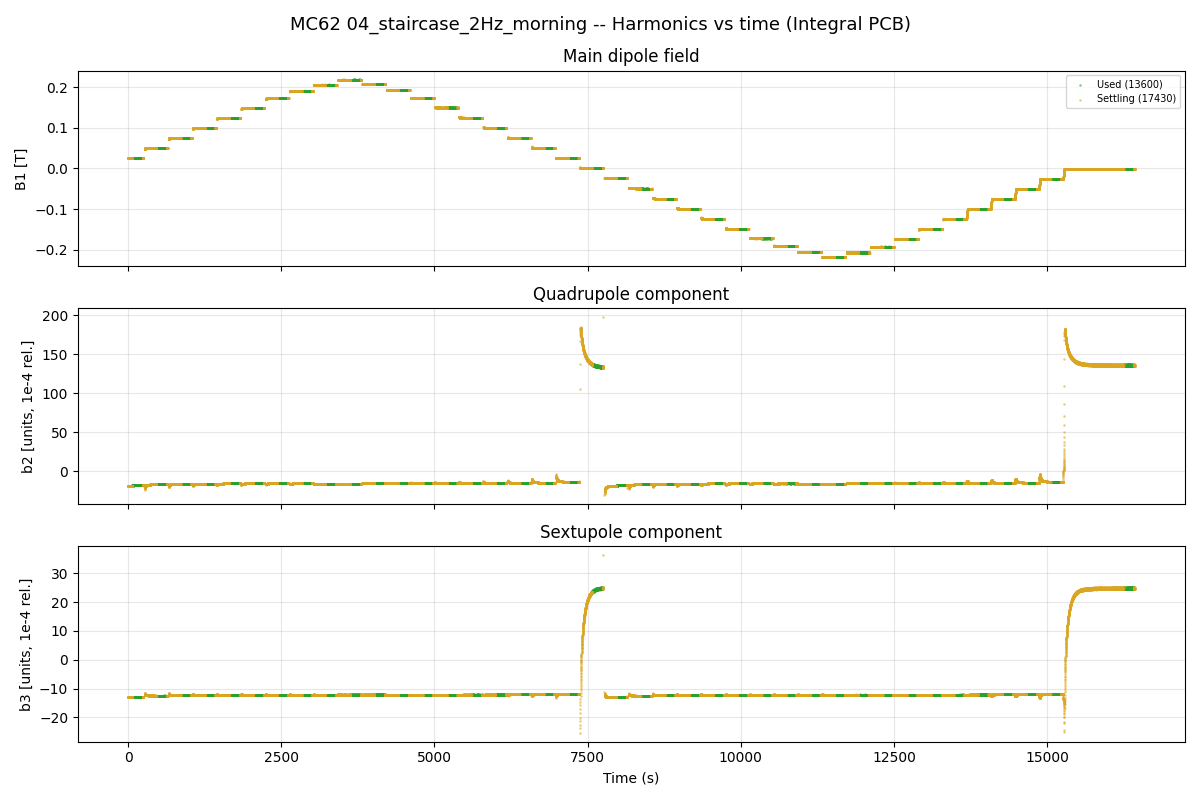

In [12]:
# ── Map pipeline rows back to turn indices for classification ──────────
_plateau_idx = np.array(sorted(turn_run_map.keys()))
_cat_plateau = cat[_plateau_idx]
_t_plateau = t_mean[_plateau_idx]
_ok = df_int["ok_main"].values.astype(bool)

_FIELD_STYLE = {
    "used":     ("tab:green",  "Used"),
    "settling": ("goldenrod",  "Settling"),
}

# ── 3-panel figure: B1, b2, b3 vs time ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for cname, (color, label) in _FIELD_STYLE.items():
    mask = _cat_plateau == cname
    n = mask.sum()
    if n == 0:
        continue
    axes[0].scatter(_t_plateau[mask], df_int["B1_T"].values[mask],
                    s=1, alpha=0.4, color=color, label=f"{label} ({n})", zorder=2)
    # b2, b3: only where ok_main (B1 > threshold, so bn is meaningful)
    m_ok = mask & _ok
    axes[1].scatter(_t_plateau[m_ok], df_int["b2_units"].values[m_ok],
                    s=1, alpha=0.4, color=color, zorder=2)
    axes[2].scatter(_t_plateau[m_ok], df_int["b3_units"].values[m_ok],
                    s=1, alpha=0.4, color=color, zorder=2)

axes[0].set_ylabel("B1 [T]")
axes[0].set_title("Main dipole field")
axes[0].legend(fontsize=7, loc="upper right")

axes[1].set_ylabel("b2 [units, 1e-4 rel.]")
axes[1].set_title("Quadrupole component")

axes[2].set_ylabel("b3 [units, 1e-4 rel.]")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Sextupole component")

fig.suptitle("MC62 04_staircase_2Hz_morning -- Harmonics vs time (Integral PCB)",
             fontsize=13)
fig.tight_layout()
plt.show()

### Harmonics vs time -- all turns (including ramps)

Process **every** turn (plateau + ramp + precycle) through the pipeline to see
the field evolution during current ramps.  Two views: full timeline and zoomed
excluding |I| <= 20 A to avoid b2/b3 blow-up near I = 0.

Processing ALL turns through pipeline (Integral PCB)...
  0-5000: done
  5000-10000: done
  10000-15000: done
  15000-20000: done
  20000-25000: done
  25000-30000: done
  30000-32544: done

All turns: 32544 rows


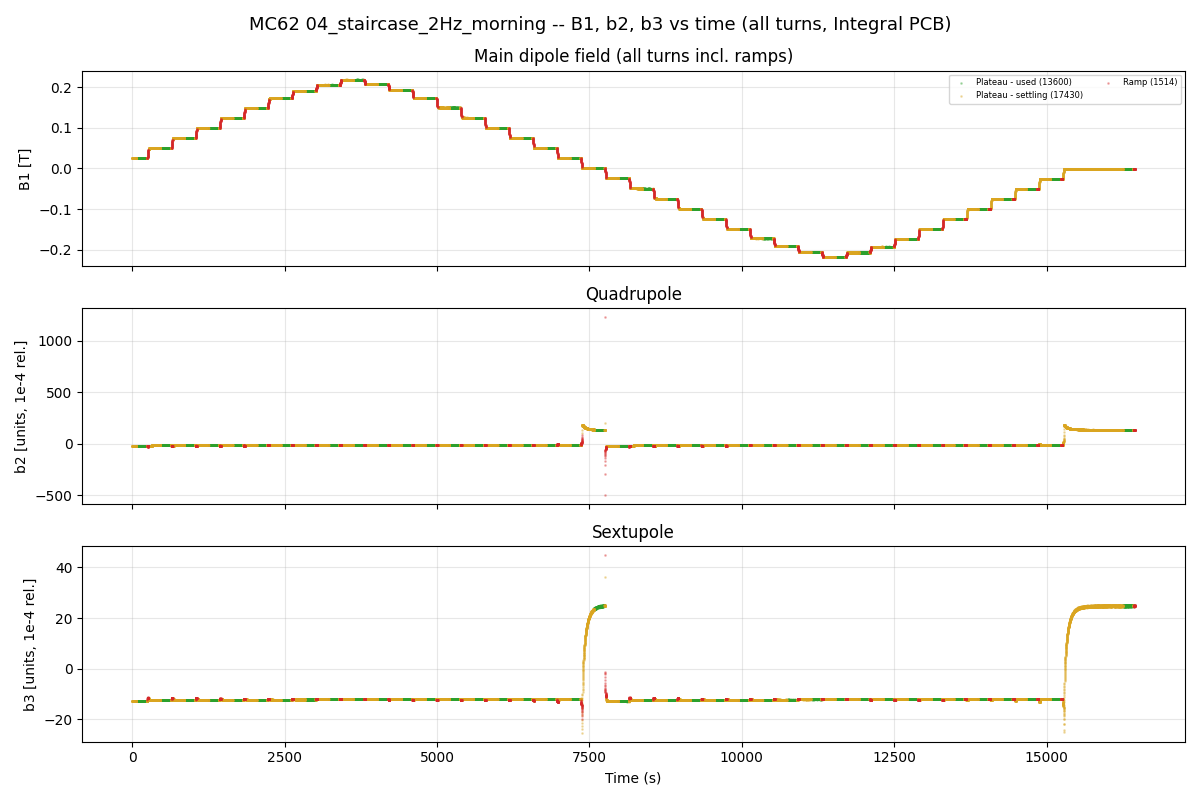

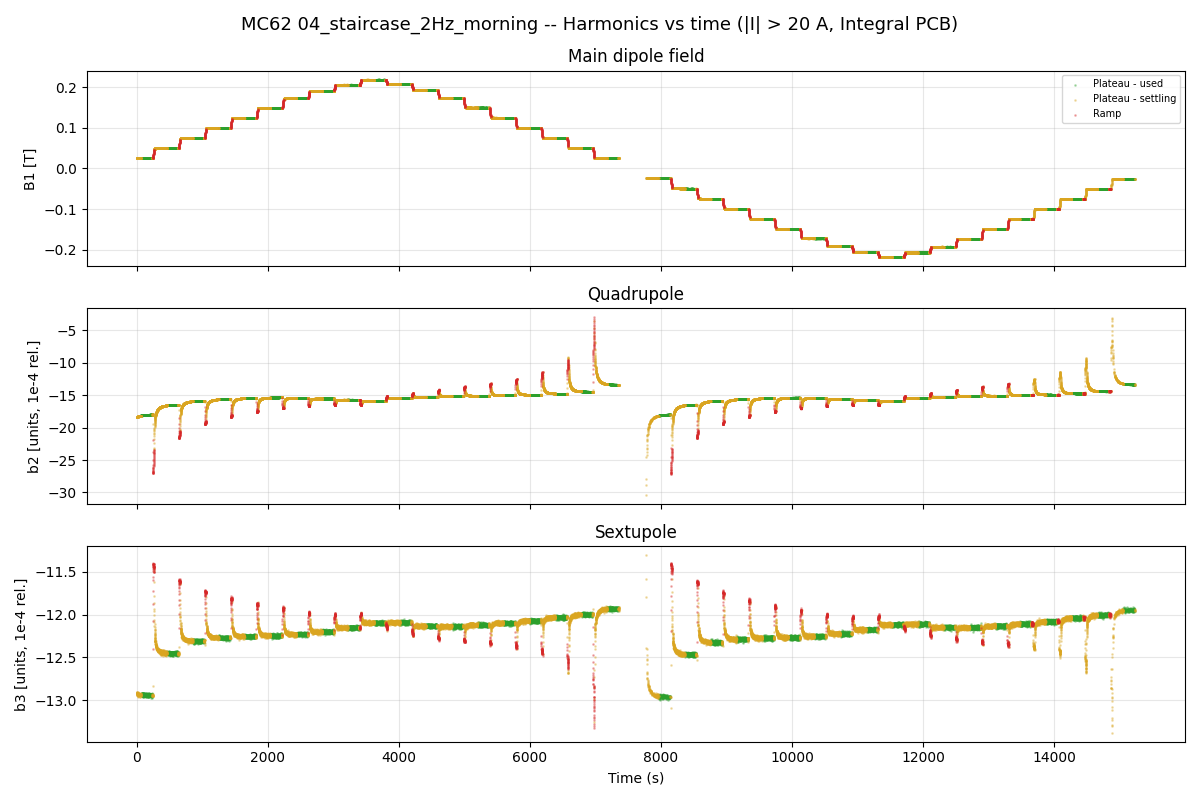

In [13]:
# ── Process ALL turns for field-vs-time visualization ──────────────────
print("Processing ALL turns through pipeline (Integral PCB)...")
_CHUNK = 5000
_all_rows = []
for _cs in range(0, n_turns_int, _CHUNK):
    _ce = min(_cs + _CHUNK, n_turns_int)
    _idx = np.arange(_cs, _ce)
    _res, _Cm, _Cu, _ok = process_kn_pipeline(
        flux_abs_int[_idx], flux_cmp_int[_idx],
        t_int[_idx], I_int[_idx],
        kn=kn_integral, r_ref=R_REF, magnet_order=MAGNET_ORDER,
        options=OPTIONS, drift_mode=DRIFT_MODE, min_b1_T=MIN_B1_T,
        merge_mode="abs_upto_m_cmp_above",
    )
    _extra = [{"global_turn": int(t)} for t in _idx]
    _all_rows.extend(build_harmonic_rows(_res, _Cm, _Cu, _ok, MAGNET_ORDER, _extra))
    print(f"  {_cs}-{_ce}: done")

df_all = pd.DataFrame(_all_rows)
if FLIP_FIELD_SIGN:
    _abs_cols = [c for c in df_all.columns if c.endswith("_T")]
    df_all[_abs_cols] *= -1
print(f"\nAll turns: {len(df_all)} rows")

# ── Full harmonics-vs-time with all categories ────────────────────────
_ok_all = df_all["ok_main"].values.astype(bool)

_ALL_STYLE = {
    "used":      ("tab:green",  "Plateau - used"),
    "settling":  ("goldenrod",  "Plateau - settling"),
    "ramp":      ("tab:red",    "Ramp"),
    "precycle":  ("grey",       "Precycle"),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for cname, (color, label) in _ALL_STYLE.items():
    mask = cat == cname
    n = mask.sum()
    if n == 0:
        continue
    axes[0].scatter(t_mean[mask], df_all["B1_T"].values[mask],
                    s=1, alpha=0.3, color=color, label=f"{label} ({n})", zorder=2)
    m_ok = mask & _ok_all
    if m_ok.sum() > 0:
        axes[1].scatter(t_mean[m_ok], df_all["b2_units"].values[m_ok],
                        s=1, alpha=0.3, color=color, zorder=2)
        axes[2].scatter(t_mean[m_ok], df_all["b3_units"].values[m_ok],
                        s=1, alpha=0.3, color=color, zorder=2)

axes[0].set_ylabel("B1 [T]")
axes[0].set_title("Main dipole field (all turns incl. ramps)")
axes[0].legend(fontsize=6, loc="upper right", ncol=2)
axes[1].set_ylabel("b2 [units, 1e-4 rel.]")
axes[1].set_title("Quadrupole")
axes[2].set_ylabel("b3 [units, 1e-4 rel.]")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Sextupole")
fig.suptitle("MC62 04_staircase_2Hz_morning -- B1, b2, b3 vs time (all turns, Integral PCB)",
             fontsize=13)
fig.tight_layout()
plt.show()

# ── Zoomed: exclude |I| <= 20 A (removes I=0 plateaus + first ramp) ──
_I_cut = 20
_hi_I = np.abs(I_mean) > _I_cut

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for cname, (color, label) in _ALL_STYLE.items():
    mask = (cat == cname) & _hi_I
    if mask.sum() == 0:
        continue
    axes[0].scatter(t_mean[mask], df_all["B1_T"].values[mask],
                    s=1, alpha=0.3, color=color, label=label, zorder=2)
    m_ok = mask & _ok_all
    if m_ok.sum() > 0:
        axes[1].scatter(t_mean[m_ok], df_all["b2_units"].values[m_ok],
                        s=1, alpha=0.3, color=color, zorder=2)
        axes[2].scatter(t_mean[m_ok], df_all["b3_units"].values[m_ok],
                        s=1, alpha=0.3, color=color, zorder=2)

axes[0].set_ylabel("B1 [T]")
axes[0].set_title("Main dipole field")
axes[0].legend(fontsize=7, loc="upper right")
axes[1].set_ylabel("b2 [units, 1e-4 rel.]")
axes[1].set_title("Quadrupole")
axes[2].set_ylabel("b3 [units, 1e-4 rel.]")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Sextupole")
fig.suptitle(f"MC62 04_staircase_2Hz_morning -- Harmonics vs time (|I| > {_I_cut} A, Integral PCB)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 8. Plateau Quality & Averaging

Select the last N turns per plateau to let eddy currents settle.

In [14]:
from rotating_coil_analyzer.analysis.utility_functions import plateau_summary, plot_hysteresis

summ_int = plateau_summary(df_int, N_LAST_TURNS, n_skip_end=N_SKIP_END)
summ_cen = plateau_summary(df_cen, N_LAST_TURNS, n_skip_end=N_SKIP_END)

cols_show = ["run_id", "I_nom", "branch", "n_ok",
             "B1_mean", "B1_std", "quality"]
print("=== Integral PCB (R45) ===")
print(summ_int[cols_show].to_string(index=False, float_format="%.6f"))
print(f"\n=== Central PCB (DQ) ===")
print(summ_cen[cols_show].to_string(index=False, float_format="%.6f"))

=== Integral PCB (R45) ===
 run_id       I_nom     branch  n_ok   B1_mean   B1_std quality
      0   20.000000  ascending   340  0.024540 0.000009    good
      1   40.000000  ascending   340  0.049501 0.000019    good
      2   60.000000  ascending   340  0.074443 0.000028    good
      3   80.000000  ascending   340  0.099349 0.000037    good
      4  100.000000  ascending   340  0.124189 0.000048    good
      5  120.000000  ascending   340  0.148858 0.000056    good
      6  140.000000  ascending   340  0.172369 0.000059    good
      7  160.000000  ascending   340  0.191367 0.000072    good
      8  180.000000  ascending   340  0.206179 0.000077    good
      9  200.000000  ascending   340  0.218460 0.000088    good
     10  180.000000 descending   340  0.206898 0.000077    good
     11  160.000000 descending   340  0.192361 0.000074    good
     12  140.000000 descending   340  0.173474 0.000069    good
     13  120.000000 descending   340  0.149698 0.000060    good
     14  100.

## 9. B1 (Main Dipole Field) vs Current â€” Hysteresis

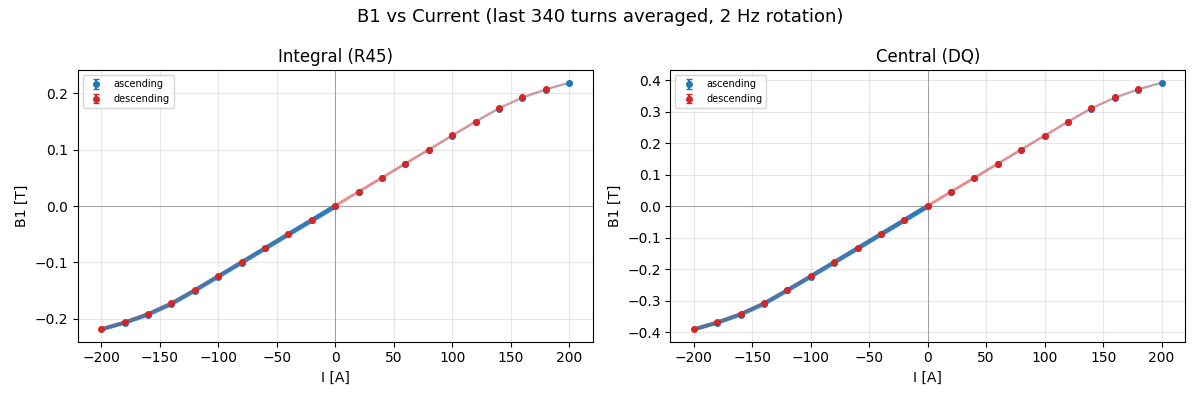

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "B1_mean", "B1_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

fig.suptitle(f"B1 vs Current (last {N_LAST_TURNS} turns averaged, 2 Hz rotation)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 10. b2 (Quadrupole) vs Current

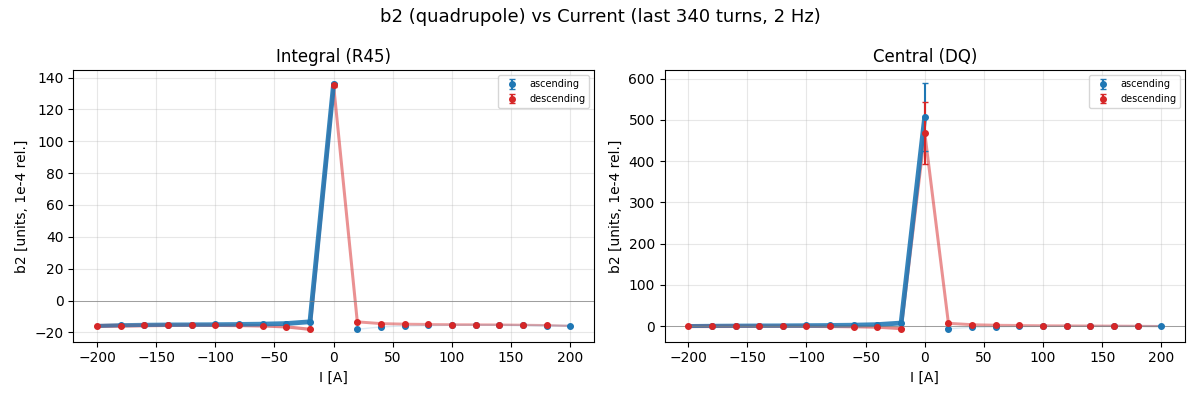

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b2_units_mean", "b2_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b2 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b2 (quadrupole) vs Current (last {N_LAST_TURNS} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 11. b3 (Sextupole) vs Current

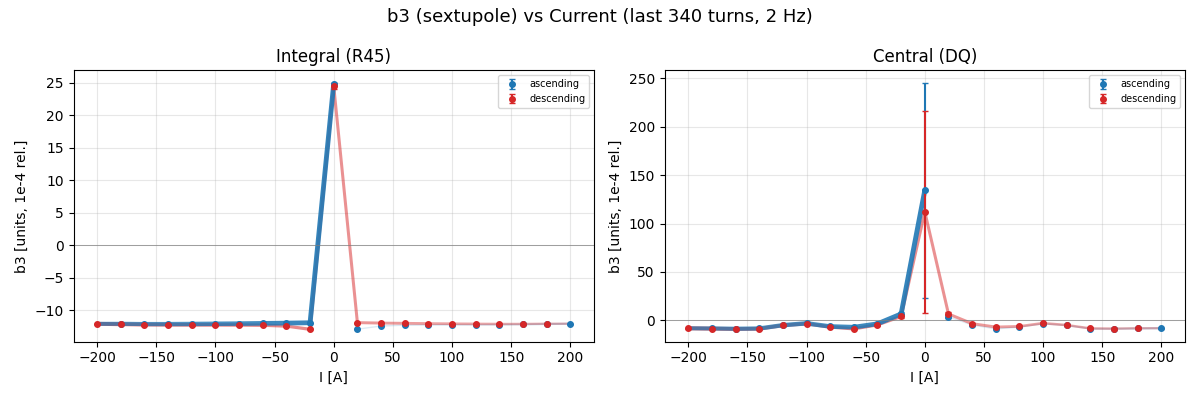

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b3_units_mean", "b3_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b3 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b3 (sextupole) vs Current (last {N_LAST_TURNS} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 12. Transfer Function B1/I vs I

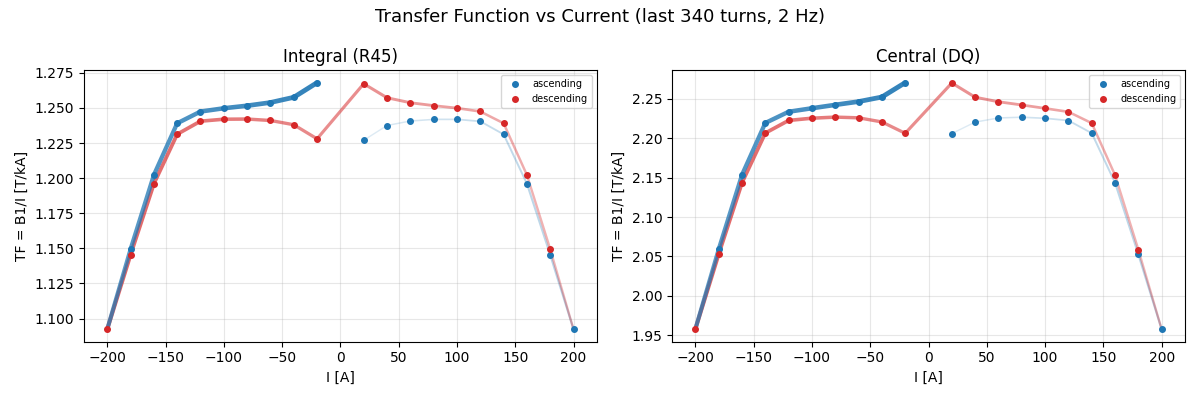

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "TF")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("TF = B1/I [T/kA]")
    ax.set_title(label)
    ax.legend(fontsize=7)

fig.suptitle(f"Transfer Function vs Current (last {N_LAST_TURNS} turns, 2 Hz)",
             fontsize=13)
fig.tight_layout()
plt.show()

## Harmonic hysteresis — excluding I ≈ 0 A plateaus

At I = 0 the relative harmonics (bn = Bn/B1) blow up because B1 → 0.
The plots below exclude |I_nom| ≤ 2 A to show the physical hysteresis.

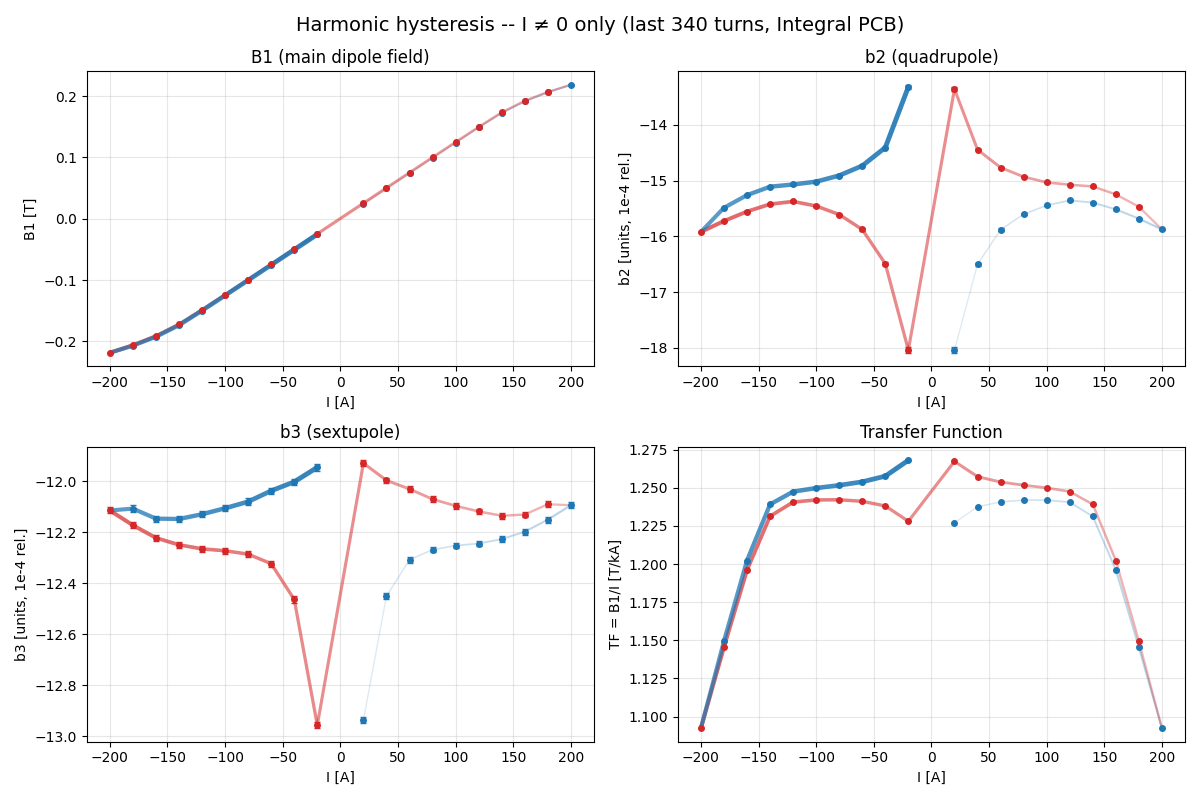

In [19]:
# ── Zoomed hysteresis: exclude I ≈ 0 A plateaus ──
mask_nz = summ_int["I_nom"].abs() > 2.0
summ_nz = summ_int[mask_nz].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_hysteresis(axes[0, 0], summ_nz, "I_nom", "B1_mean", "B1_std")
axes[0, 0].set_xlabel("I [A]")
axes[0, 0].set_ylabel("B1 [T]")
axes[0, 0].set_title("B1 (main dipole field)")

plot_hysteresis(axes[0, 1], summ_nz, "I_nom", "b2_units_mean", "b2_units_std")
axes[0, 1].set_xlabel("I [A]")
axes[0, 1].set_ylabel("b2 [units, 1e-4 rel.]")
axes[0, 1].set_title("b2 (quadrupole)")

plot_hysteresis(axes[1, 0], summ_nz, "I_nom", "b3_units_mean", "b3_units_std")
axes[1, 0].set_xlabel("I [A]")
axes[1, 0].set_ylabel("b3 [units, 1e-4 rel.]")
axes[1, 0].set_title("b3 (sextupole)")

plot_hysteresis(axes[1, 1], summ_nz, "I_nom", "TF")
axes[1, 1].set_xlabel("I [A]")
axes[1, 1].set_ylabel("TF = B1/I [T/kA]")
axes[1, 1].set_title("Transfer Function")

fig.suptitle(f"Harmonic hysteresis -- I ≠ 0 only (last {N_LAST_TURNS} turns, Integral PCB)",
             fontsize=14)
fig.tight_layout()
plt.show()

## 13. Multipole Spectrum at Peak Current

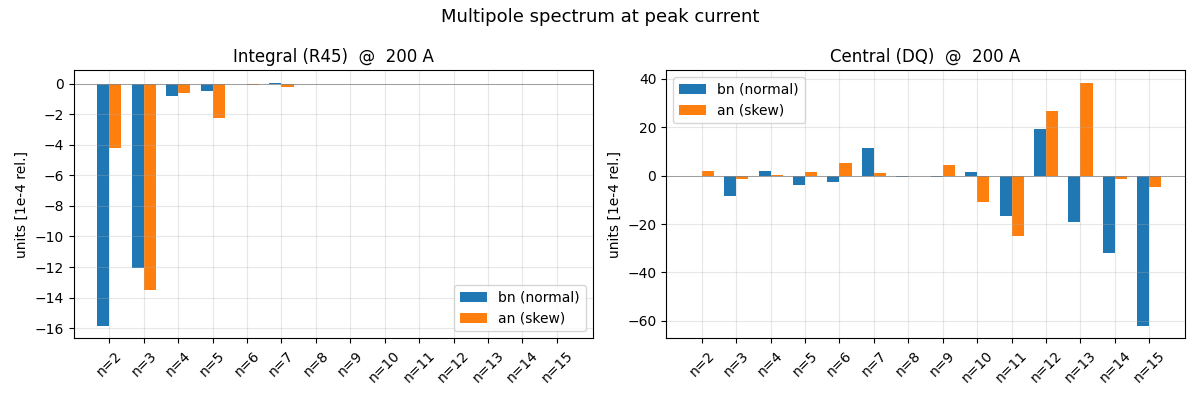

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    good = summ[summ["quality"] == "good"]
    if good.empty:
        ax.set_title(f"{label}: no valid data")
        continue
    peak = good.loc[good["I_nom"].abs().idxmax()]

    orders, bn, an = [], [], []
    for n in range(2, 16):
        bc = f"b{n}_units_mean"
        ac = f"a{n}_units_mean"
        if bc in summ.columns and pd.notna(peak.get(bc)):
            orders.append(n)
            bn.append(peak[bc])
            an.append(peak.get(ac, 0.0) if pd.notna(peak.get(ac)) else 0.0)

    if orders:
        x = np.arange(len(orders))
        w = 0.35
        ax.bar(x - w/2, bn, w, label="bn (normal)", color="tab:blue")
        ax.bar(x + w/2, an, w, label="an (skew)", color="tab:orange")
        ax.set_xticks(x)
        ax.set_xticklabels([f"n={o}" for o in orders], rotation=45)
        ax.set_ylabel("units [1e-4 rel.]")
        ax.set_title(f"{label}  @  {peak['I_nom']:.0f} A")
        ax.legend()
        ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Multipole spectrum at peak current", fontsize=13)
fig.tight_layout()
plt.show()

## 14. Summary Table

In [21]:
def format_summary(summ, label):
    print(f"\n{'=' * 90}")
    print(f"  {label}")
    print(f"  R_ref = {R_REF*1e3:.1f} mm  |  "
          f"last {N_LAST_TURNS} turns averaged  |  2 Hz rotation")
    print(f"{'=' * 90}")
    hdr = (f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
           f"{'B1 [T]':>12s} {'b2 [units]':>12s} "
           f"{'b3 [units]':>12s} {'TF [T/kA]':>10s} {'Qual':>5s}")
    print(hdr)
    print("-" * 90)
    for _, r in summ.iterrows():
        b1 = f"{r['B1_mean']:.6f}" if pd.notna(r['B1_mean']) else "---"
        b2 = (f"{r.get('b2_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b2_units_mean')) else "---")
        b3 = (f"{r.get('b3_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b3_units_mean')) else "---")
        tf = f"{r['TF']:.4f}" if pd.notna(r['TF']) else "---"
        print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} "
              f"{r['branch']:>10s} {b1:>12s} {b2:>12s} "
              f"{b3:>12s} {tf:>10s} {r['quality']:>5s}")

format_summary(summ_int, "Integral PCB (R45)")
format_summary(summ_cen, "Central PCB (DQ)")


  Integral PCB (R45)
  R_ref = 33.0 mm  |  last 340 turns averaged  |  2 Hz rotation
 Run    I [A]     Branch       B1 [T]   b2 [units]   b3 [units]  TF [T/kA]  Qual
------------------------------------------------------------------------------------------
   0    +20.0  ascending     0.024540       -18.04       -12.94     1.2270  good
   1    +40.0  ascending     0.049501       -16.50       -12.45     1.2375  good
   2    +60.0  ascending     0.074443       -15.88       -12.31     1.2407  good
   3    +80.0  ascending     0.099349       -15.60       -12.27     1.2419  good
   4   +100.0  ascending     0.124189       -15.44       -12.25     1.2419  good
   5   +120.0  ascending     0.148858       -15.35       -12.24     1.2405  good
   6   +140.0  ascending     0.172369       -15.39       -12.23     1.2312  good
   7   +160.0  ascending     0.191367       -15.51       -12.20     1.1960  good
   8   +180.0  ascending     0.206179       -15.68       -12.15     1.1454  good
   9   +200.0

---
## 15. Golden Standard Parity Check â€” Our Pipeline vs FFMM (C++)

Compare our per-turn results against the FFMM C++ analyzer output.
Both pipelines process the same raw binary data.

**FFMM convention**: `R_REF = 0.33 m`, 15 harmonics.  
**Our convention**: `R_REF = 0.033 m`, 30 harmonics (integral).  

For parity, we re-run our pipeline with `R_REF = 0.33 m` on **all** turns
(matching FFMM which processes every turn, not just plateaus) and compare
`B_main` (T, R_REF-independent) and harmonics at the same reference radius.

**Note**: FFMM Central results are all NaN (embedded Central Kn was all-zeros).
Parity check is Integral only.

In [22]:
# Load FFMM per-turn results (Integral only â€” Central is all NaN)
ffmm = pd.read_csv(str(FFMM_INTEGRAL), sep="\t", skipinitialspace=True)
ffmm.columns = [c.strip() for c in ffmm.columns]
n_ffmm = len(ffmm)
print(f"FFMM Integral results: {n_ffmm} turns")
print(f"  Time span: {ffmm['Time(s)'].iloc[0]:.1f} â€“ {ffmm['Time(s)'].iloc[-1]:.1f} s")
print(f"  Rref = {ffmm['Rref(m)'].iloc[0]} m, Lcoil = {ffmm['Lcoil(m)'].iloc[0]} m")
print(f"  Columns: {list(ffmm.columns[:15])} ...")

# Verify Central is NaN
ffmm_cen_check = pd.read_csv(str(FFMM_CENTRAL), sep="\t", nrows=5)
print(f"\nFFMM Central B_main sample: {ffmm_cen_check['B_main(T)'].tolist()}")
print("  -> All NaN (Central Kn was all-zeros in measurement). Parity = Integral only.")

FFMM Integral results: 32508 turns
  Time span: 0.3 â€“ 16428.5 s
  Rref = 0.33 m, Lcoil = 1.2 m
  Columns: ['Time(s)', 'Duration(s)', 'Options', 'Rref(m)', 'Lcoil(m)', 'I(A)', 'Ramprate(A/s)', 'dx(mm)', 'dy(mm)', 'phi(rad)', 'B_main(T)', 'A_main(T)', 'B_main_TF(T/kA)', 'A_main_TF(T/kA)', 'B1(T)'] ...

FFMM Central B_main sample: [nan, nan, nan, nan, nan]
  -> All NaN (Central Kn was all-zeros in measurement). Parity = Integral only.


In [23]:
# Re-run our pipeline on ALL turns with R_REF=0.33 for parity comparison
# Use 15-harmonic Kn (matching FFMM's n_multipoles=15) from measurement file
KN_MEAS_INTEGRAL = MEAS_DIR / "MC62_20260217_094521_staircase_2Hz_Kn_values_Ap_1_Seg_Integral.txt"
kn_parity = load_segment_kn_txt(str(KN_MEAS_INTEGRAL))
print(f"Parity Kn: {len(kn_parity.orders)} harmonics (from measurement file)")

# Process in chunks to avoid memory issues (35828 turns x 512 samples)
n_all = min(n_turns_int, n_ffmm)  # match FFMM turn count
print(f"Processing {n_all} turns with R_REF={FFMM_R_REF} m for parity...")
print(f"Parity options: {PARITY_OPTIONS}  (dit_signed=True to match C++ native)")

CHUNK = 5000
all_parity_rows = []
for c_start in range(0, n_all, CHUNK):
    c_end = min(c_start + CHUNK, n_all)
    idx = np.arange(c_start, c_end)

    result_p, C_merged_p, C_units_p, ok_main_p = process_kn_pipeline(
        flux_abs_turns=flux_abs_int[idx],
        flux_cmp_turns=flux_cmp_int[idx],
        t_turns=t_int[idx],
        I_turns=I_int[idx],
        kn=kn_parity,
        r_ref=FFMM_R_REF,
        magnet_order=MAGNET_ORDER,
        options=PARITY_OPTIONS,
        drift_mode=DRIFT_MODE,
        min_b1_T=MIN_B1_T,
        merge_mode="abs_upto_m_cmp_above",
        dit_signed=True,
    )

    extra = [{"global_turn": int(t)} for t in idx]
    rows = build_harmonic_rows(result_p, C_merged_p, C_units_p, ok_main_p,
                               MAGNET_ORDER, extra)
    all_parity_rows.extend(rows)
    print(f"  chunk {c_start}â€“{c_end}: done")

df_parity = pd.DataFrame(all_parity_rows)
print(f"\nParity DataFrame: {len(df_parity)} rows")

Parity Kn: 15 harmonics (from measurement file)
Processing 32508 turns with R_REF=0.33 m for parity...
Parity options: ('dri', 'rot', 'cel', 'fed', 'dit')  (dit_signed=True to match C++ native)
  chunk 0â€“5000: done
  chunk 5000â€“10000: done
  chunk 10000â€“15000: done
  chunk 15000â€“20000: done
  chunk 20000â€“25000: done
  chunk 25000â€“30000: done
  chunk 30000â€“32508: done

Parity DataFrame: 32508 rows


  PARITY CHECK: B_main (T)  â€”  Our pipeline vs FFMM C++
  Turns compared: 32508
  Max |diff|:     2.246644e-12 T
  Mean |diff|:    1.576104e-16 T
  RMS diff:       1.340534e-14 T
  Median |diff|:  2.775558e-17 T

  Relative (|B_main| > 0.01 T, 29453 turns):
  Max  |rel diff|: 8.853161e-11
  Mean |rel diff|: 5.046991e-15
  Median:          2.694207e-16


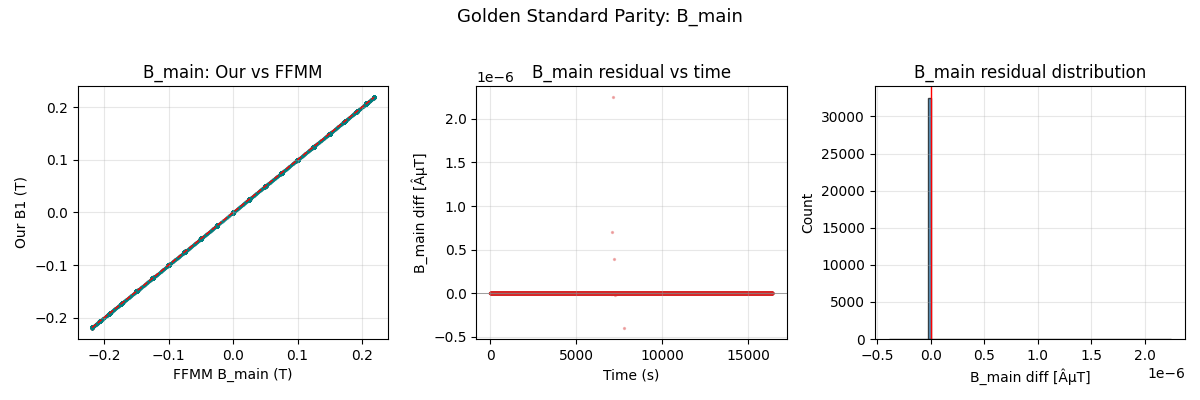

In [24]:
# Compare B_main (our B1_T vs FFMM B_main(T))
our_B1 = df_parity["B1_T"].values[:n_ffmm]
ffmm_B1 = ffmm["B_main(T)"].values

diff_B1 = our_B1 - ffmm_B1
abs_diff = np.abs(diff_B1)

print("=" * 70)
print("  PARITY CHECK: B_main (T)  â€”  Our pipeline vs FFMM C++")
print("=" * 70)
print(f"  Turns compared: {n_ffmm}")
print(f"  Max |diff|:     {abs_diff.max():.6e} T")
print(f"  Mean |diff|:    {abs_diff.mean():.6e} T")
print(f"  RMS diff:       {np.sqrt(np.mean(diff_B1**2)):.6e} T")
print(f"  Median |diff|:  {np.median(abs_diff):.6e} T")

# Relative difference where |B_main| > 0.01 T
mask_ok = np.abs(ffmm_B1) > 0.01
rel_diff = np.abs(diff_B1[mask_ok] / ffmm_B1[mask_ok])
print(f"\n  Relative (|B_main| > 0.01 T, {mask_ok.sum()} turns):")
print(f"  Max  |rel diff|: {rel_diff.max():.6e}")
print(f"  Mean |rel diff|: {rel_diff.mean():.6e}")
print(f"  Median:          {np.median(rel_diff):.6e}")

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax = axes[0]
ax.scatter(ffmm_B1, our_B1, s=2, alpha=0.3, c="teal")
lims = [ffmm_B1.min(), ffmm_B1.max()]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("FFMM B_main (T)")
ax.set_ylabel("Our B1 (T)")
ax.set_title("B_main: Our vs FFMM")

ax = axes[1]
ax.scatter(df_parity["time_s"].values[:n_ffmm], diff_B1 * 1e6,
           s=2, alpha=0.3, c="tab:red")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("B_main diff [ÂµT]")
ax.set_title("B_main residual vs time")

ax = axes[2]
ax.hist(diff_B1 * 1e6, bins=100, color="tab:blue", alpha=0.7, edgecolor="black")
ax.axvline(0, color="red", lw=1)
ax.set_xlabel("B_main diff [ÂµT]")
ax.set_ylabel("Count")
ax.set_title("B_main residual distribution")

fig.suptitle("Golden Standard Parity: B_main", fontsize=13)
fig.tight_layout()
plt.show()

In [25]:
# Compare harmonics (b2, b3) at FFMM's R_REF=0.33
print("=" * 70)
print("  PARITY CHECK: Harmonics  â€”  Our vs FFMM (Rref = 0.33 m)")
print("=" * 70)

# Only compare where B_main is meaningful (|I| > 10 A and ok_main)
mask_harm = (np.abs(ffmm["I(A)"].values) > 10) & df_parity["ok_main"].values[:n_ffmm]
n_harm = mask_harm.sum()
print(f"  Turns for harmonic comparison: {n_harm} (|I| > 10 A and ok_main)")

for n_ord in range(2, 11):
    bn_col = f"b{n_ord}_units"
    an_col = f"a{n_ord}_units"
    ffmm_bn_col = f"b{n_ord}(Units)"
    ffmm_an_col = f"a{n_ord}(Units)"

    if bn_col not in df_parity.columns or ffmm_bn_col not in ffmm.columns:
        continue

    our_bn = df_parity[bn_col].values[:n_ffmm][mask_harm]
    ffmm_bn = ffmm[ffmm_bn_col].values[mask_harm]
    diff_bn = our_bn - ffmm_bn
    rms_bn = np.sqrt(np.mean(diff_bn**2))

    our_an = df_parity[an_col].values[:n_ffmm][mask_harm]
    ffmm_an = ffmm[ffmm_an_col].values[mask_harm]
    diff_an = our_an - ffmm_an
    rms_an = np.sqrt(np.mean(diff_an**2))

    print(f"  b{n_ord}: RMS diff = {rms_bn:.4f} units, "
          f"max |diff| = {np.abs(diff_bn).max():.4f} | "
          f"a{n_ord}: RMS = {rms_an:.4f}, max = {np.abs(diff_an).max():.4f}")

  PARITY CHECK: Harmonics  â€”  Our vs FFMM (Rref = 0.33 m)
  Turns for harmonic comparison: 29388 (|I| > 10 A and ok_main)
  b2: RMS diff = 0.0000 units, max |diff| = 0.0000 | a2: RMS = 0.0000, max = 0.0000
  b3: RMS diff = 0.0000 units, max |diff| = 0.0003 | a3: RMS = 0.0000, max = 0.0003
  b4: RMS diff = 0.0002 units, max |diff| = 0.0278 | a4: RMS = 0.0001, max = 0.0084
  b5: RMS diff = 0.0037 units, max |diff| = 0.4745 | a5: RMS = 0.0090, max = 1.4150
  b6: RMS diff = 0.2527 units, max |diff| = 30.7361 | a6: RMS = 0.3070, max = 48.1981
  b7: RMS diff = 11.9384 units, max |diff| = 1731.1017 | a7: RMS = 6.9897, max = 840.1116
  b8: RMS diff = 303.2090 units, max |diff| = 36165.5316 | a8: RMS = 295.8463, max = 27450.7198
  b9: RMS diff = 7296.0800 units, max |diff| = 656642.8743 | a9: RMS = 8423.9448, max = 977039.8711
  b10: RMS diff = 185187.2325 units, max |diff| = 12782914.6664 | a10: RMS = 165821.3027, max = 12671604.2400


In [26]:
# Detailed comparison table: sample turns from each plateau
# Pick the middle settled turn from each staircase plateau
print("\nDetailed per-plateau parity (middle settled turn):")
print(f"{'Turn':>7s} {'I(A)':>8s} {'B1_ours':>12s} {'B1_FFMM':>12s} {'dB1[uT]':>10s} "
      f"{'b2_ours':>10s} {'b2_FFMM':>10s} {'db2':>8s} "
      f"{'b3_ours':>10s} {'b3_FFMM':>10s} {'db3':>8s}")
print("-" * 120)

for _, grp in staircase_groups.iterrows():
    mid_turn = int((grp["start"] + grp["end"]) // 2)
    if mid_turn >= n_ffmm:
        continue

    B1_o = df_parity.loc[mid_turn, "B1_T"] if mid_turn < len(df_parity) else np.nan
    B1_f = ffmm.loc[mid_turn, "B_main(T)"]
    dB1 = (B1_o - B1_f) * 1e6 if pd.notna(B1_o) and pd.notna(B1_f) else np.nan

    b2_o = df_parity.loc[mid_turn, "b2_units"] if "b2_units" in df_parity.columns and mid_turn < len(df_parity) else np.nan
    b2_f = ffmm.loc[mid_turn, "b2(Units)"]
    db2 = b2_o - b2_f if pd.notna(b2_o) and pd.notna(b2_f) else np.nan

    b3_o = df_parity.loc[mid_turn, "b3_units"] if "b3_units" in df_parity.columns and mid_turn < len(df_parity) else np.nan
    b3_f = ffmm.loc[mid_turn, "b3(Units)"]
    db3 = b3_o - b3_f if pd.notna(b3_o) and pd.notna(b3_f) else np.nan

    I_a = ffmm.loc[mid_turn, "I(A)"]

    def fmt(v, f=".4f"): return f"{v:{f}}" if pd.notna(v) else "---"

    print(f"{mid_turn:7d} {I_a:+8.1f} {fmt(B1_o, '.6f'):>12s} {fmt(B1_f, '.6f'):>12s} "
          f"{fmt(dB1, '+.1f'):>10s} "
          f"{fmt(b2_o):>10s} {fmt(b2_f):>10s} {fmt(db2, '+.2f'):>8s} "
          f"{fmt(b3_o):>10s} {fmt(b3_f):>10s} {fmt(db3, '+.2f'):>8s}")


Detailed per-plateau parity (middle settled turn):
   Turn     I(A)      B1_ours      B1_FFMM    dB1[uT]    b2_ours    b2_FFMM      db2    b3_ours    b3_FFMM      db3
------------------------------------------------------------------------------------------------------------------------
    244    +20.0    -0.024525    -0.024525       -0.0  -171.2392  -171.2392    -0.00 -1290.4851 -1290.4851    +0.00
    899    +40.0    -0.049466    -0.049466       +0.0  -152.7124  -152.7124    +0.00 -1225.1712 -1225.1712    -0.00
   1680    +60.0    -0.074439    -0.074439       -0.0  -142.9278  -142.9278    +0.00 -1204.3354 -1204.3354    +0.00
   2463    +80.0    -0.099292    -0.099292       +0.0  -135.7650  -135.7650    -0.00 -1200.1748 -1200.1748    +0.00
   3245   +100.0    -0.124223    -0.124223       +0.0  -132.1579  -132.1579    +0.00 -1197.2092 -1197.2092    +0.00
   4026   +120.0    -0.148836    -0.148836       +0.0  -126.4123  -126.4123    -0.00 -1192.6119 -1192.6119    +0.00
   4808   +140.

## 16. Export to CSV (optional)

In [27]:
# Uncomment to save:
# out = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\output")
# out.mkdir(exist_ok=True)
# summ_int.to_csv(out / "MC62_04_staircase_2Hz_morning_integral_summary.csv", index=False)
# summ_cen.to_csv(out / "MC62_04_staircase_2Hz_morning_central_summary.csv", index=False)
# df_int.to_csv(out / "MC62_04_staircase_2Hz_morning_integral_all_turns.csv", index=False)
# df_cen.to_csv(out / "MC62_04_staircase_2Hz_morning_central_all_turns.csv", index=False)
# print("Saved to", out)

## Analysis Choices Summary

Key parameters used in this analysis, for reproducibility and cross-comparison.

In [28]:
_cel_fed_status = diag.recommendation if "diag" in dir() else "N/A"

choices = pd.DataFrame({
    "Parameter": [
        "Samples/turn",
        "Rotation speed",
        "N_LAST_TURNS (settled)",
        "N_SKIP_END",
        "Plateau detection threshold",
        "Pipeline OPTIONS",
        "cel/fed diagnostic",
        "DRIFT_MODE",
        "R_REF (m)",
        "MAGNET_ORDER",
        "FLIP_FIELD_SIGN",
        "MIN_B1_T (ok_main threshold)",
    ],
    "Value": [
        str(SAMPLES_PER_TURN),
        f"{RPM} rpm ({RPM/60:.1f} Hz)",
        str(N_LAST_TURNS),
        str(N_SKIP_END),
        f"{PLATEAU_I_RANGE_MAX} A",
        str(OPTIONS),
        _cel_fed_status,
        DRIFT_MODE,
        str(R_REF),
        f"{MAGNET_ORDER} (dipole)",
        str(FLIP_FIELD_SIGN),
        str(MIN_B1_T),
    ],
})

choices.style.hide(axis="index")

Parameter,Value
Samples/turn,512
Rotation speed,120 rpm (2.0 Hz)
N_LAST_TURNS (settled),340
N_SKIP_END,20
Plateau detection threshold,0.5 A
Pipeline OPTIONS,"('dri', 'rot')"
cel/fed diagnostic,UNSAFE
DRIFT_MODE,legacy
R_REF (m),0.033
MAGNET_ORDER,1 (dipole)
